# Class 09: KNN and Deployment with Gradio

Train a KNN regressor, choose K using validation data, save the fitted Pipeline, and connect it to a Gradio interface.

---
## Generate House Data

We will use a small synthetic dataset so that the notebook can focus on how KNN works.

In [3]:
import numpy as np

np.random.seed(42)

n_samples = 100
sq_feet = np.random.randint(500, 3000, n_samples)
bedrooms = np.random.randint(1, 6, n_samples)
price = 50000 + sq_feet * 100 + bedrooms * 20000 + np.random.normal(0, 20000, n_samples)

X = np.column_stack([sq_feet, bedrooms])
y = price

print(f"Generated {n_samples} houses")
print(f"Features: square feet and bedrooms | X shape: {X.shape}")
print(f"Target: price | y shape: {y.shape}")

Generated 100 houses
Features: square feet and bedrooms | X shape: (100, 2)
Target: price | y shape: (100,)


---
## Create Training, Validation, and Test Sets

Training data fits the models, validation data chooses K, and test data is used once for final evaluation.

In [4]:
import numpy
import scipy
import sklearn

print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)

NumPy: 1.24.4
SciPy: 1.9.1
Scikit-learn: 1.0.2


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_remaining, y_train, y_remaining = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_remaining, y_remaining, test_size=0.5, random_state=42
)

print(f"Training: {len(X_train)} | Validation: {len(X_validation)} | Test: {len(X_test)}")

Training: 60 | Validation: 20 | Test: 20


---
## Why Scaling Matters

Square feet and bedrooms have very different numeric ranges. We compare the same KNN model before and after scaling.

In [6]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

knn_without_scaling = KNeighborsRegressor(n_neighbors=5)
knn_without_scaling.fit(X_train, y_train)
prediction_without_scaling = knn_without_scaling.predict(X_validation)

print(f"Validation R² without scaling: {r2_score(y_validation, prediction_without_scaling):.3f}")

Validation R² without scaling: 0.707


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

scaled_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=5))
])
scaled_knn.fit(X_train, y_train)
prediction_with_scaling = scaled_knn.predict(X_validation)

print(f"Validation R² with scaling: {r2_score(y_validation, prediction_with_scaling):.3f}")

Validation R² with scaling: 0.851


---
## Choose K Using Validation MSE

Fit each candidate on the training set and choose the K with the lowest validation MSE. The test set remains untouched.

In [8]:
from sklearn.metrics import mean_squared_error

k_values = list(range(1, 31))
validation_mse = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])
    model.fit(X_train, y_train)
    validation_prediction = model.predict(X_validation)
    validation_mse.append(mean_squared_error(y_validation, validation_prediction))

best_k = k_values[np.argmin(validation_mse)]
print(f"Selected K: {best_k}")
print(f"Lowest validation MSE: {min(validation_mse):,.0f}")

Selected K: 2
Lowest validation MSE: 738,592,402


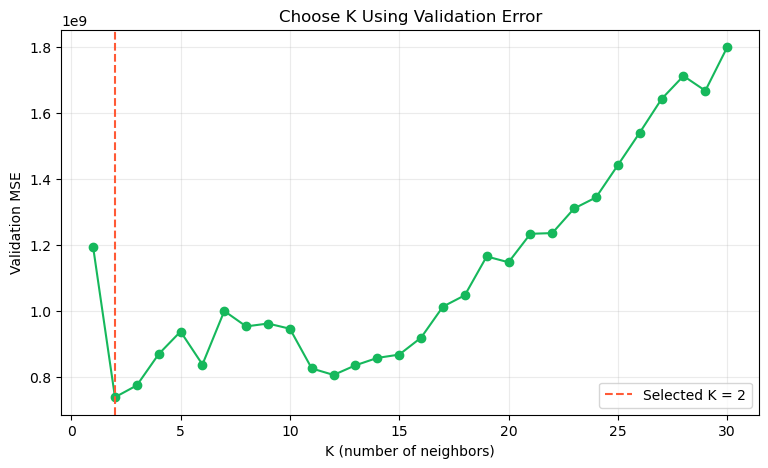

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(k_values, validation_mse, color="#16B85C", marker="o")
plt.axvline(best_k, color="#FF5A36", linestyle="--", label=f"Selected K = {best_k}")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Validation MSE")
plt.title("Choose K Using Validation Error")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

---
## Fit the Final Pipeline and Evaluate Once

K is now locked. Combine the training and validation sets, refit the Pipeline, and evaluate it once on the untouched test set.

In [10]:
X_final_train = np.vstack([X_train, X_validation])
y_final_train = np.concatenate([y_train, y_validation])

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=best_k))
])
final_pipeline.fit(X_final_train, y_final_train)
test_prediction = final_pipeline.predict(X_test)

print(f"Final K: {best_k}")
print(f"Test MSE: {mean_squared_error(y_test, test_prediction):,.0f}")
print(f"Test R²: {r2_score(y_test, test_prediction):.3f}")

Final K: 2
Test MSE: 731,462,518
Test R²: 0.861


---
## Save and Load the Fitted Pipeline

The fitted StandardScaler and KNN model are saved together in one file.

In [11]:
import joblib

joblib.dump(final_pipeline, "house_price_pipeline.joblib")
loaded_pipeline = joblib.load("house_price_pipeline.joblib")

print("Saved and loaded house_price_pipeline.joblib")

Saved and loaded house_price_pipeline.joblib


---
## Create the Prediction Function

The function receives user values, calls the fitted Pipeline, and returns a readable result.

In [12]:
def predict_price(sq_feet, bedrooms):
    house = np.array([[sq_feet, bedrooms]])
    prediction = loaded_pipeline.predict(house)[0]
    return f"Predicted price: ${prediction:,.0f}"

predict_price(2000, 3)

'Predicted price: $273,364'

---
## Visualize the Selected Neighbors

Because the Pipeline scales the features before KNN, the plot uses standardized feature values. The highlighted labels show the known prices that are averaged for the prediction.

In [13]:
def predict_with_neighbors(sq_feet, bedrooms):
    house = np.array([[sq_feet, bedrooms]])
    prediction = loaded_pipeline.predict(house)[0]

    scaler = loaded_pipeline.named_steps["scaler"]
    knn = loaded_pipeline.named_steps["knn"]
    scaled_training = scaler.transform(X_final_train)
    scaled_house = scaler.transform(house)
    _, indices = knn.kneighbors(scaled_house)
    neighbors = indices[0]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(scaled_training[:, 0], scaled_training[:, 1], color="#AAB8C8", alpha=0.55, label="Other houses")
    ax.scatter(scaled_training[neighbors, 0], scaled_training[neighbors, 1], color="#16B85C", s=110, label=f"{best_k} nearest neighbors")
    ax.scatter(scaled_house[0, 0], scaled_house[0, 1], color="#FF5A36", marker="*", s=260, label="New house")

    for index in neighbors:
        ax.plot([scaled_house[0, 0], scaled_training[index, 0]], [scaled_house[0, 1], scaled_training[index, 1]], color="#16B85C", linestyle="--", alpha=0.5)
        ax.annotate(f"${y_final_train[index]:,.0f}", (scaled_training[index, 0], scaled_training[index, 1]), xytext=(5, 6), textcoords="offset points")

    ax.set_xlabel("Standardized square feet")
    ax.set_ylabel("Standardized bedrooms")
    ax.set_title(f"Prediction = average of {best_k} neighbor prices = ${prediction:,.0f}")
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()

    return f"Predicted price: ${prediction:,.0f}", fig

---
## Build One Gradio Interface

Run the installation cell only when Gradio is not already available.

In [14]:
#%pip install -q gradio

In [ ]:
import gradio as gr
gr.Plot(label="Selected neighbors", format="png")
demo = gr.Interface(
    fn=predict_with_neighbors,
    inputs=[
        gr.Slider(500, 3000, value=2000, step=10, label="Square feet"),
        gr.Slider(1, 5, value=3, step=1, label="Bedrooms")
    ],
    outputs=[gr.Textbox(label="Prediction"), gr.Plot(label="Selected neighbors")],
    title="House Price Predictor",
    description=f"Uses the K = {best_k} selected from validation data."
)

<class 'tuple'>
('Predicted price: $172,201', <Figure size 800x500 with 1 Axes>)


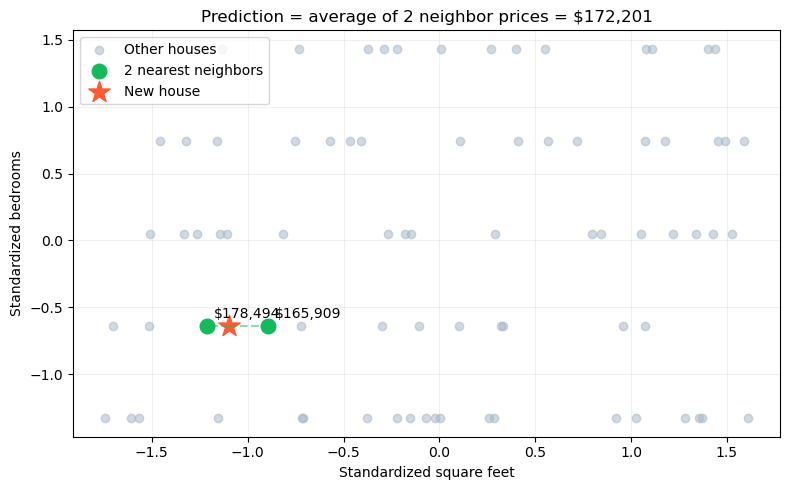

In [22]:
result = predict_with_neighbors(1000, 2)
print(type(result))
print(result)

In [ ]:
demo.launch(share=True, debug=True)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Running on public URL: https://387c2fb92754498717.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.9/site-packages/gradio/queueing.py", line 536, in process_events
    response = await route_utils.call_process_api(
  File "/opt/anaconda3/lib/python3.9/site-packages/gradio/route_utils.py", line 322, in call_process_api
    output = await app.get_blocks().process_api(
  File "/opt/anaconda3/lib/python3.9/site-packages/gradio/blocks.py", line 1945, in process_api
    data = await self.postprocess_data(block_fn, result["prediction"], state)
  File "/opt/anaconda3/lib/python3.9/site-packages/gradio/blocks.py", line 1768, in postprocess_data
    prediction_value = block.postprocess(prediction_value)
  File "/opt/anaconda3/lib/python3.9/site-packages/gradio/components/plot.py", line 139, in postprocess
    out_y = processing_utils.encode_plot_to_base64(value, self.format)
  File "/opt/anaconda3/lib/python3.9/site-packages/gradio/processing_utils.py", line 138, in encode_plot_to_base64
    plt.savefig(output_bytes, format

In [ ]:
# demo.launch(share=True)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Running on public URL: https://387c2fb92754498717.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.9/site-packages/gradio/queueing.py", line 536, in process_events
    response = await route_utils.call_process_api(
  File "/opt/anaconda3/lib/python3.9/site-packages/gradio/route_utils.py", line 322, in call_process_api
    output = await app.get_blocks().process_api(
  File "/opt/anaconda3/lib/python3.9/site-packages/gradio/blocks.py", line 1945, in process_api
    data = await self.postprocess_data(block_fn, result["prediction"], state)
  File "/opt/anaconda3/lib/python3.9/site-packages/gradio/blocks.py", line 1768, in postprocess_data
    prediction_value = block.postprocess(prediction_value)
  File "/opt/anaconda3/lib/python3.9/site-packages/gradio/components/plot.py", line 139, in postprocess
    out_y = processing_utils.encode_plot_to_base64(value, self.format)
  File "/opt/anaconda3/lib/python3.9/site-packages/gradio/processing_utils.py", line 138, in encode_plot_to_base64
    plt.savefig(output_bytes, format

---
## Temporary Link and Hosted Deployment

`share=True` exposes the locally running app through a temporary public link. The link stops working when the notebook session ends.

For a persistent deployment, upload the application files to a Hugging Face Space. The deployed application loads the same fitted Pipeline for every prediction; it does not retrain the model for each user.